# Complementariedad entre SAN y PosFormer en CROHME 2014

Este notebook carga simultáneamente SAN y PosFormer en GPU y evalúa ambos modelos sobre las mismas 986 imágenes de CROHME 2014. Las muestras se alinean por ID, nunca por posición en los archivos de anotaciones.

Se presentan dos evaluaciones:

1. **Nativa:** SAN se compara con Modelo1 y PosFormer con Modelo2. Sirve para relacionar estos resultados con los benchmarks individuales.
2. **Común normalizada (principal):** las dos predicciones se comparan con la anotación de Modelo2 después de normalizar espacios y retirar `\limits`. Esta evaluación determina cuántas expresiones aciertan ambos modelos, solo SAN, solo PosFormer o ninguno.

> El notebook no calcula FLOPs ni ejecuta `torch.profiler`, pues su propósito es estudiar la complementariedad de las predicciones.

In [1]:
from pathlib import Path
import gc, json, os, platform, sys, time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / '..', Path.cwd() / '../..']
    for candidate in candidates:
        candidate = candidate.resolve()
        if all((candidate / name).is_dir() for name in ('SAN', 'PosFormer', 'data')):
            return candidate
    raise FileNotFoundError('No se encontró la raíz con SAN/, PosFormer/ y data/.')

ROOT = find_project_root()
SAN_ROOT = ROOT / 'SAN'
POS_ROOT = ROOT / 'PosFormer'
RESULTS_DIR = ROOT / 'Cascada' / '01_seleccion' / 'resultados'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda:0')
assert torch.cuda.is_available(), 'CUDA no está disponible.'
print('Raíz   :', ROOT)
print('GPU    :', torch.cuda.get_device_name(0))
print('PyTorch:', torch.__version__)

Raíz   : C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch: 2.0.1+cu118


## Configuración y correspondencia de los tests

Modelo1 y Modelo2 contienen las mismas imágenes, pero cambian el nombre, el orden y 85 anotaciones. Se usa la copia de Modelo2 como entrada visual común y se conservan las dos etiquetas por ID.

In [2]:
YEAR = '2014'
MAX_SAMPLES = None       # Use un entero para una prueba corta.
WARMUP_RUNS = 3
PROGRESS_EVERY = 25
EXAMPLES_PER_CATEGORY = 5

M1_DIR = ROOT / 'data' / 'Modelo1' / YEAR
M2_DIR = ROOT / 'data' / 'Modelo2' / YEAR
COMMON_IMAGE_DIR = M2_DIR / 'img'

def read_captions(path):
    captions = {}
    order = []
    for line_number, line in enumerate(path.read_text(encoding='utf-8').splitlines(), start=1):
        parts = line.strip().split()
        if not parts:
            continue
        sample_id = parts[0][:-4] if parts[0].endswith('.jpg') else parts[0]
        if sample_id in captions:
            raise ValueError(f'ID duplicado en {path.name}, línea {line_number}: {sample_id}')
        captions[sample_id] = ' '.join(parts[1:])
        order.append(sample_id)
    return captions, order

captions_m1, order_m1 = read_captions(M1_DIR / 'test_caption.txt')
captions_m2, order_m2 = read_captions(M2_DIR / 'caption.txt')
ids_m1, ids_m2 = set(captions_m1), set(captions_m2)
if ids_m1 != ids_m2:
    raise ValueError(f'Los inventarios no coinciden: solo M1={len(ids_m1-ids_m2)}, solo M2={len(ids_m2-ids_m1)}')

sample_ids = order_m2[:MAX_SAMPLES] if MAX_SAMPLES is not None else order_m2
missing_images = [sample_id for sample_id in sample_ids if not (COMMON_IMAGE_DIR / f'{sample_id}.bmp').is_file()]
if missing_images:
    raise FileNotFoundError(f'Faltan {len(missing_images)} imágenes; primera: {missing_images[0]}')

annotation_differences = sum(captions_m1[sample_id] != captions_m2[sample_id] for sample_id in sample_ids)
inventory = pd.DataFrame({
    'indicador': ['IDs Modelo1', 'IDs Modelo2', 'IDs comunes seleccionados', 'anotaciones diferentes'],
    'cantidad': [len(ids_m1), len(ids_m2), len(sample_ids), annotation_differences],
})
display(inventory)

,indicador,cantidad
0,IDs Modelo1,986
1,IDs Modelo2,986
2,IDs comunes seleccionados,986
3,anotaciones diferentes,85


## Carga de SAN y PosFormer en GPU

In [3]:
sys.path.insert(0, str(SAN_ROOT))
from utils import load_config
from infer.Backbone import Backbone
from dataset import Words

san_params = load_config(SAN_ROOT / '14.yaml')
san_params['device'] = DEVICE
san_params['word_path'] = str(SAN_ROOT / 'data' / 'word.txt')
san_params['checkpoint'] = str(SAN_ROOT / 'checkpoints' / 'SAN_decoder' / 'best.pth')
san_words = Words(san_params['word_path'])
san_params['word_num'] = len(san_words)
san_params['struct_num'] = 7
san_params['words'] = san_words

san_model = Backbone(san_params)
san_state = torch.load(san_params['checkpoint'], map_location='cpu', weights_only=True)
san_model.load_state_dict(san_state['model'])
san_model = san_model.to(DEVICE).eval().requires_grad_(False)

print('SAN cargado:', san_params['checkpoint'])
print(f'Parámetros SAN: {sum(p.numel() for p in san_model.parameters()):,}')

try UTF-8 encoding
115 symbols in total


c:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\.venv-hmer-gpu\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


SAN cargado: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\SAN\checkpoints\SAN_decoder\best.pth
Parámetros SAN: 7,996,103


In [4]:
sys.path.insert(0, str(POS_ROOT))
from Pos_Former.lit_posformer import LitPosFormer
from Pos_Former.datamodule.transforms import ScaleToLimitRange
from Pos_Former.datamodule import vocab

pos_checkpoints = sorted((POS_ROOT / 'lightning_logs' / 'version_0' / 'checkpoints').glob('*.ckpt'))
if not pos_checkpoints:
    raise FileNotFoundError('No se encontró un checkpoint de PosFormer.')
pos_checkpoint = next((path for path in pos_checkpoints if path.name == 'best.ckpt'), pos_checkpoints[0])
pos_model = LitPosFormer.load_from_checkpoint(str(pos_checkpoint), map_location='cpu')
pos_model = pos_model.to(DEVICE).eval().requires_grad_(False)
torch.cuda.synchronize()

print('PosFormer cargado:', pos_checkpoint)
print(f'Parámetros PosFormer: {sum(p.numel() for p in pos_model.parameters()):,}')
print(f'VRAM asignada con ambos modelos: {torch.cuda.memory_allocated() / 1024**2:.2f} MiB')

c:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\.venv-hmer-gpu\lib\site-packages\pytorch_lightning\utilities\migration\migration.py:203: PossibleUserWarning: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
  rank_zero_warn(
Lightning automatically upgraded your loaded checkpoint from v1.4.9 to v2.0.9. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\PosFormer\lightning_logs\version_0\checkpoints\best.ckpt`


PosFormer cargado: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\PosFormer\lightning_logs\version_0\checkpoints\best.ckpt
Parámetros PosFormer: 9,632,236
VRAM asignada con ambos modelos: 68.64 MiB


## Preparación, decodificación y normalización

Cada modelo recibe la misma imagen, pero conserva su preprocesamiento oficial. La normalización común elimina únicamente `\limits` y diferencias de espacios; no intenta declarar equivalentes otras expresiones LaTeX.

In [5]:
pos_scale_transform = ScaleToLimitRange(w_lo=16, w_hi=1024, h_lo=16, h_hi=256)

def load_grayscale(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return image

def prepare_san(image):
    tensor = torch.from_numpy(image.copy()).float().div_(255).unsqueeze(0).unsqueeze(0)
    mask = torch.ones_like(tensor)
    return tensor.to(DEVICE), mask.to(DEVICE)

def prepare_posformer(image):
    transformed = pos_scale_transform(image)
    tensor = torch.from_numpy(transformed.copy()).float().div_(255).unsqueeze(0).unsqueeze(0)
    _, _, height, width = tensor.shape
    mask = torch.zeros((1, height, width), dtype=torch.bool)
    return tensor.to(DEVICE), mask.to(DEVICE), (height, width)

def san_prediction_to_latex(prediction):
    if prediction is None or len(prediction) <= 1:
        return '<sin predicción>'
    children = {}
    for item in prediction:
        if len(item) < 4:
            continue
        try:
            node_id, parent_id = int(item[1]), int(item[2])
        except (TypeError, ValueError):
            continue
        children.setdefault(parent_id, []).append((node_id, str(item[3])))

    def walk(node_id):
        if node_id < 0 or node_id >= len(prediction):
            return ['<invalid>']
        symbol = str(prediction[node_id][0])
        kids = children.get(node_id, [])
        if not kids:
            return [symbol]
        result = [symbol]
        if symbol == r'\frac':
            for relation_name in ('Above', 'Below'):
                for child_id, relation in kids:
                    if relation == relation_name:
                        result += ['{'] + walk(child_id) + ['}']
            for child_id, relation in kids:
                if relation == 'Right':
                    result += walk(child_id)
            return result
        for child_id, relation in kids:
            if relation == 'l_sup':
                result += ['['] + walk(child_id) + [']']
        for child_id, relation in kids:
            if relation == 'Inside':
                result += ['{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation in ('Sub', 'Below'):
                result += ['_', '{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation in ('Sup', 'Above'):
                result += ['^', '{'] + walk(child_id) + ['}']
        for child_id, relation in kids:
            if relation == 'Right':
                result += walk(child_id)
        return result

    try:
        return ' '.join(walk(1))
    except Exception as exc:
        return f'<error SAN: {exc}>'

def posformer_prediction_to_latex(hypotheses):
    if hypotheses is None or len(hypotheses) == 0:
        return '<sin hipótesis>'
    return vocab.indices2label(hypotheses[0].seq)

def normalize_spaces(text):
    return ' '.join(str(text).split())

def normalize_common(text):
    return ' '.join(token for token in str(text).split() if token != r'\limits')

def classify(san_correct, pos_correct):
    if san_correct and pos_correct:
        return 'Ambos aciertan'
    if san_correct:
        return 'Solo SAN'
    if pos_correct:
        return 'Solo PosFormer'
    return 'Ambos fallan'

## Calentamiento

El calentamiento usa la primera imagen y no forma parte de los resultados.

In [6]:
first_image = load_grayscale(COMMON_IMAGE_DIR / f'{sample_ids[0]}.bmp')
san_image, san_mask = prepare_san(first_image)
pos_image, pos_mask, _ = prepare_posformer(first_image)
with torch.inference_mode():
    for _ in range(WARMUP_RUNS):
        san_output = san_model(san_image, san_mask)
        torch.cuda.synchronize()
        del san_output
    for _ in range(WARMUP_RUNS):
        pos_output = pos_model.approximate_joint_search(pos_image, pos_mask)
        torch.cuda.synchronize()
        del pos_output
del first_image, san_image, san_mask, pos_image, pos_mask
gc.collect()
torch.cuda.synchronize()
print(f'Calentamiento terminado: {WARMUP_RUNS} ejecuciones por modelo.')

Calentamiento terminado: 3 ejecuciones por modelo.


## Inferencia pareada

Cada fila conserva las dos referencias, las dos predicciones y los resultados bajo ambos protocolos. Los tiempos se incluyen solo como información auxiliar y no sustituyen los benchmarks individuales.

In [7]:
rows = []
for index, sample_id in enumerate(sample_ids, start=1):
    image_path = COMMON_IMAGE_DIR / f'{sample_id}.bmp'
    row = {
        'index': index, 'sample_id': sample_id, 'image_file': image_path.name,
        'ground_truth_modelo1': captions_m1[sample_id],
        'ground_truth_modelo2': captions_m2[sample_id],
        'status': 'ok', 'error': '',
    }
    try:
        image = load_grayscale(image_path)
        height, width = image.shape
        row.update({'height': height, 'width': width})

        san_image, san_mask = prepare_san(image)
        torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.inference_mode():
            san_raw = san_model(san_image, san_mask)
        torch.cuda.synchronize()
        san_time_ms = (time.perf_counter() - start) * 1000
        san_prediction = san_prediction_to_latex(san_raw)
        del san_raw, san_image, san_mask

        pos_image, pos_mask, (pos_height, pos_width) = prepare_posformer(image)
        torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.inference_mode():
            pos_raw = pos_model.approximate_joint_search(pos_image, pos_mask)
        torch.cuda.synchronize()
        pos_time_ms = (time.perf_counter() - start) * 1000
        pos_prediction = posformer_prediction_to_latex(pos_raw)
        del pos_raw, pos_image, pos_mask, image

        gt_m1_native = normalize_spaces(captions_m1[sample_id])
        gt_m2_native = normalize_spaces(captions_m2[sample_id])
        san_native_correct = normalize_spaces(san_prediction) == gt_m1_native
        pos_native_correct = normalize_spaces(pos_prediction) == gt_m2_native

        common_ground_truth = normalize_common(captions_m2[sample_id])
        san_common_prediction = normalize_common(san_prediction)
        pos_common_prediction = normalize_common(pos_prediction)
        san_common_correct = san_common_prediction == common_ground_truth
        pos_common_correct = pos_common_prediction == common_ground_truth

        row.update({
            'posformer_height': pos_height, 'posformer_width': pos_width,
            'san_prediction': san_prediction, 'posformer_prediction': pos_prediction,
            'san_time_ms': san_time_ms, 'posformer_time_ms': pos_time_ms,
            'san_native_correct': int(san_native_correct),
            'posformer_native_correct': int(pos_native_correct),
            'native_outcome': classify(san_native_correct, pos_native_correct),
            'common_ground_truth': common_ground_truth,
            'san_common_prediction': san_common_prediction,
            'posformer_common_prediction': pos_common_prediction,
            'san_common_correct': int(san_common_correct),
            'posformer_common_correct': int(pos_common_correct),
            'common_outcome': classify(san_common_correct, pos_common_correct),
        })
    except Exception as exc:
        row.update({'status': 'error', 'error': f'{type(exc).__name__}: {exc}'})
        if 'out of memory' in str(exc).lower():
            rows.append(row)
            raise
    rows.append(row)
    gc.collect()
    if index == 1 or index % PROGRESS_EVERY == 0 or index == len(sample_ids):
        valid_now = [item for item in rows if item['status'] == 'ok']
        san_hits = sum(item['san_common_correct'] for item in valid_now)
        pos_hits = sum(item['posformer_common_correct'] for item in valid_now)
        print(f'{index:4d}/{len(sample_ids)} | válidas={len(valid_now):4d} | SAN={san_hits:4d} | PosFormer={pos_hits:4d}')

   1/986 | válidas=   1 | SAN=   1 | PosFormer=   1
  25/986 | válidas=  25 | SAN=  21 | PosFormer=  21
  50/986 | válidas=  50 | SAN=  36 | PosFormer=  36
  75/986 | válidas=  75 | SAN=  52 | PosFormer=  54
 100/986 | válidas= 100 | SAN=  73 | PosFormer=  74
 125/986 | válidas= 125 | SAN=  92 | PosFormer=  96
 150/986 | válidas= 150 | SAN= 112 | PosFormer= 113
 175/986 | válidas= 175 | SAN= 128 | PosFormer= 132
 200/986 | válidas= 200 | SAN= 140 | PosFormer= 144
 225/986 | válidas= 225 | SAN= 159 | PosFormer= 163
 250/986 | válidas= 250 | SAN= 178 | PosFormer= 182
 275/986 | válidas= 275 | SAN= 194 | PosFormer= 200
 300/986 | válidas= 300 | SAN= 215 | PosFormer= 220
 325/986 | válidas= 325 | SAN= 231 | PosFormer= 240
 350/986 | válidas= 350 | SAN= 246 | PosFormer= 259
 375/986 | válidas= 375 | SAN= 261 | PosFormer= 271
 400/986 | válidas= 400 | SAN= 273 | PosFormer= 288
 425/986 | válidas= 425 | SAN= 292 | PosFormer= 308
 450/986 | válidas= 450 | SAN= 308 | PosFormer= 328
 475/986 | v

## Resultados numéricos y archivos de salida

In [8]:
results = pd.DataFrame(rows)
valid = results.loc[results['status'] == 'ok'].copy()
errors = results.loc[results['status'] != 'ok'].copy()
if valid.empty:
    raise RuntimeError('No hubo resultados válidos.')

category_order = ['Ambos aciertan', 'Solo SAN', 'Solo PosFormer', 'Ambos fallan']
def outcome_table(column):
    counts = valid[column].value_counts().reindex(category_order, fill_value=0)
    table = counts.rename('instancias').to_frame()
    table['porcentaje'] = 100 * table['instancias'] / len(valid)
    return table

native_outcomes = outcome_table('native_outcome')
common_outcomes = outcome_table('common_outcome')
accuracy_table = pd.DataFrame({
    'evaluación': ['Nativa', 'Nativa', 'Común normalizada', 'Común normalizada'],
    'modelo': ['SAN', 'PosFormer', 'SAN', 'PosFormer'],
    'aciertos': [
        int(valid['san_native_correct'].sum()),
        int(valid['posformer_native_correct'].sum()),
        int(valid['san_common_correct'].sum()),
        int(valid['posformer_common_correct'].sum()),
    ],
})
accuracy_table['total'] = len(valid)
accuracy_table['exact_match_percent'] = 100 * accuracy_table['aciertos'] / accuracy_table['total']

oracle_hits = int((valid['common_outcome'] != 'Ambos fallan').sum())
summary = {
    'dataset': f'CROHME {YEAR}',
    'samples_requested': len(sample_ids),
    'samples_valid': len(valid),
    'errors': len(errors),
    'canonical_reference': 'Modelo2',
    'common_normalization': 'Espacios normalizados y eliminación del token \limits',
    'native_san_correct': int(valid['san_native_correct'].sum()),
    'native_posformer_correct': int(valid['posformer_native_correct'].sum()),
    'common_san_correct': int(valid['san_common_correct'].sum()),
    'common_posformer_correct': int(valid['posformer_common_correct'].sum()),
    'both_correct': int(common_outcomes.loc['Ambos aciertan', 'instancias']),
    'san_only': int(common_outcomes.loc['Solo SAN', 'instancias']),
    'posformer_only': int(common_outcomes.loc['Solo PosFormer', 'instancias']),
    'both_wrong': int(common_outcomes.loc['Ambos fallan', 'instancias']),
    'oracle_correct': oracle_hits,
    'oracle_exact_match_percent': 100 * oracle_hits / len(valid),
    'annotation_differences_m1_m2': annotation_differences,
    'gpu': torch.cuda.get_device_name(0),
    'python': platform.python_version(),
    'pytorch': torch.__version__,
}

csv_path = RESULTS_DIR / f'comparacion_san_posformer_crohme_{YEAR}.csv'
json_path = RESULTS_DIR / f'resumen_comparacion_san_posformer_crohme_{YEAR}.json'
results.to_csv(csv_path, index=False, encoding='utf-8')
json_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

print('Exact match por modelo')
display(accuracy_table.style.format({'exact_match_percent': '{:.2f}%'}))
print('Complementariedad principal: referencia Modelo2 normalizada')
display(common_outcomes.style.format({'porcentaje': '{:.2f}%'}))
print('Complementariedad con referencias nativas (informativa)')
display(native_outcomes.style.format({'porcentaje': '{:.2f}%'}))
print(f'Oracle común: {oracle_hits}/{len(valid)} ({100 * oracle_hits / len(valid):.2f}%)')
print('CSV    :', csv_path)
print('Resumen:', json_path)
if not errors.empty:
    display(errors[['sample_id', 'error']])

Exact match por modelo


,evaluación,modelo,aciertos,total,exact_match_percent
0,Nativa,SAN,558,986,56.59%
1,Nativa,PosFormer,618,986,62.68%
2,Común normalizada,SAN,560,986,56.80%
3,Común normalizada,PosFormer,618,986,62.68%


Complementariedad principal: referencia Modelo2 normalizada


,instancias,porcentaje
common_outcome,,
Ambos aciertan,511,51.83%
Solo SAN,49,4.97%
Solo PosFormer,107,10.85%
Ambos fallan,319,32.35%


Complementariedad con referencias nativas (informativa)


,instancias,porcentaje
native_outcome,,
Ambos aciertan,509,51.62%
Solo SAN,49,4.97%
Solo PosFormer,109,11.05%
Ambos fallan,319,32.35%


Oracle común: 667/986 (67.65%)
CSV    : C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\comparacion_san_posformer_crohme_2014.csv
Resumen: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\resumen_comparacion_san_posformer_crohme_2014.json


## Visualización de la complementariedad

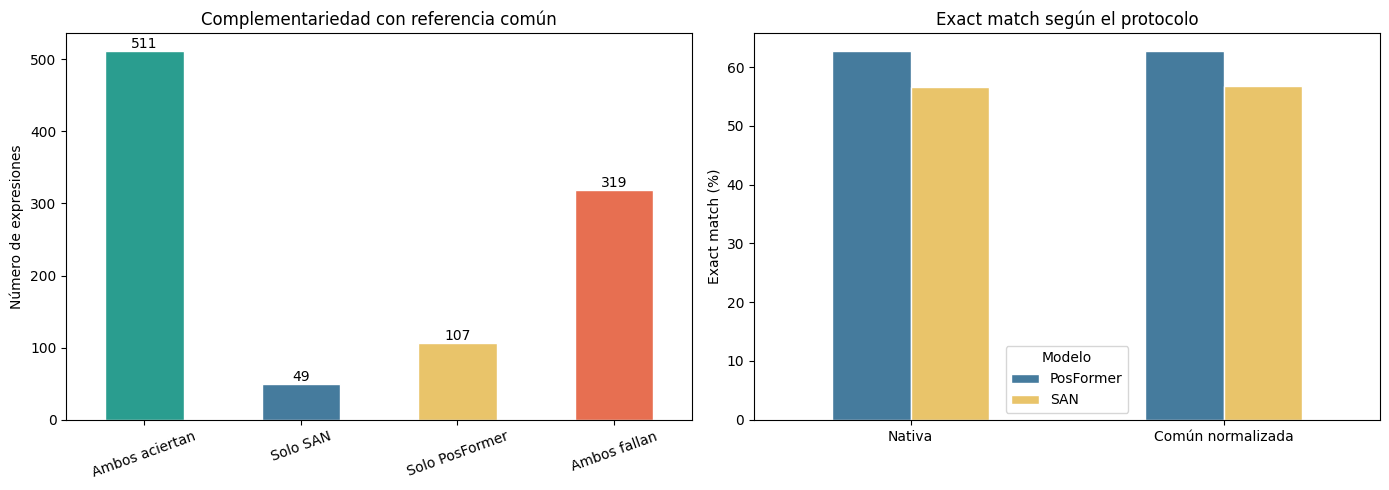

Gráfica: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\comparacion_san_posformer_crohme_2014.png


In [9]:
colors = ['#2a9d8f', '#457b9d', '#e9c46a', '#e76f51']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

common_outcomes['instancias'].plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Complementariedad con referencia común')
axes[0].set_xlabel('')
axes[0].set_ylabel('Número de expresiones')
axes[0].tick_params(axis='x', rotation=20)
for patch, value in zip(axes[0].patches, common_outcomes['instancias']):
    axes[0].annotate(str(value), (patch.get_x() + patch.get_width()/2, patch.get_height()), ha='center', va='bottom')

pivot_accuracy = accuracy_table.pivot(index='evaluación', columns='modelo', values='exact_match_percent')
pivot_accuracy = pivot_accuracy.reindex(['Nativa', 'Común normalizada'])
pivot_accuracy.plot.bar(ax=axes[1], color=['#457b9d', '#e9c46a'], edgecolor='white')
axes[1].set_title('Exact match según el protocolo')
axes[1].set_xlabel('')
axes[1].set_ylabel('Exact match (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Modelo')

fig.tight_layout()
plot_path = RESULTS_DIR / f'comparacion_san_posformer_crohme_{YEAR}.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
print('Gráfica:', plot_path)

## Ejemplos por categoría

Las tablas siguientes facilitan revisar expresiones concretas. La referencia y las predicciones mostradas son las versiones normalizadas usadas en la comparación principal.

In [10]:
example_columns = [
    'sample_id', 'common_ground_truth', 'san_common_prediction',
    'posformer_common_prediction', 'ground_truth_modelo1', 'ground_truth_modelo2',
]
for category in category_order:
    subset = valid.loc[valid['common_outcome'] == category, example_columns].head(EXAMPLES_PER_CATEGORY)
    print(f'\n{category}: {int((valid["common_outcome"] == category).sum())} instancias')
    display(subset.style.set_properties(**{'text-align': 'left'}))


Ambos aciertan: 511 instancias


,sample_id,common_ground_truth,san_common_prediction,posformer_common_prediction,ground_truth_modelo1,ground_truth_modelo2
0,23_em_52,2 p,2 p,2 p,2 p,2 p
1,513_em_320,k N,k N,k N,k N,k N
2,RIT_2014_29,- 7,- 7,- 7,- 7,- 7
3,RIT_2014_95,2 0,2 0,2 0,2 0,2 0
4,RIT_2014_97,1 2,1 2,1 2,1 2,1 2



Solo SAN: 49 instancias


,sample_id,common_ground_truth,san_common_prediction,posformer_common_prediction,ground_truth_modelo1,ground_truth_modelo2
6,RIT_2014_57,1 9,1 9,7 9,1 9,1 9
18,RIT_2014_156,- 1,- 1,- 7,- 1,- 1
43,37_em_9,y < b,y < b,y _ { < b },y < b,y < b
83,516_em_386,\{ a \},\{ a \},\{ a _ { q } \},\{ a \},\{ a \}
136,516_em_378,5 j + 3 j,5 j + 3 j,5 j + 3 8,5 j + 3 j,5 j + 3 j



Solo PosFormer: 107 instancias


,sample_id,common_ground_truth,san_common_prediction,posformer_common_prediction,ground_truth_modelo1,ground_truth_modelo2
11,511_em_257,H z,H _ { z },H z,H z,H z
23,20_em_42,1 7,1 T,1 7,1 7,1 7
47,RIT_2014_54,z < p,z < P,z < p,z < p,z < p
69,31_em_178,q + w,\phi + w,q + w,q + w,q + w
70,RIT_2014_1,k < 1,k < l,k < 1,k < 1,k < 1



Ambos fallan: 319 instancias


,sample_id,common_ground_truth,san_common_prediction,posformer_common_prediction,ground_truth_modelo1,ground_truth_modelo2
5,29_em_151,P a,p _ { a },p _ { a },P a,P a
7,517_em_404,P a,p _ { a },p _ { a },P a,P a
27,RIT_2014_9,\log,\log g,\log g,\log,\log
28,509_em_93,| S |,| s l,| s |,| S |,| S |
30,28_em_132,S / V,s / v,S / v,S / V,S / V


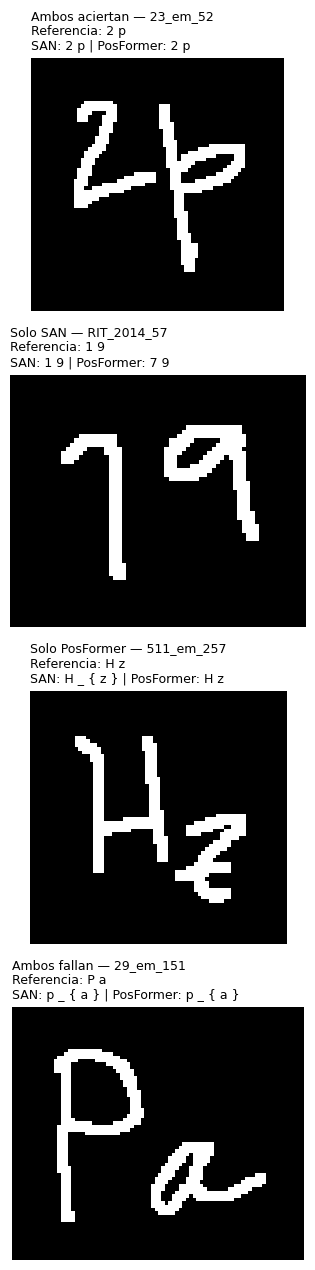

Ejemplos: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\ejemplos_comparacion_san_posformer_crohme_2014.png


In [11]:
# Muestra una imagen representativa de cada categoría disponible.
representatives = []
for category in category_order:
    subset = valid.loc[valid['common_outcome'] == category]
    if not subset.empty:
        representatives.append((category, subset.iloc[0]))

if representatives:
    fig, axes = plt.subplots(len(representatives), 1, figsize=(14, 3.2 * len(representatives)))
    axes = np.atleast_1d(axes)
    for axis, (category, row) in zip(axes, representatives):
        image = load_grayscale(COMMON_IMAGE_DIR / row['image_file'])
        axis.imshow(image, cmap='gray', vmin=0, vmax=255)
        axis.set_title(
            f"{category} — {row['sample_id']}\n"
            f"Referencia: {row['common_ground_truth']}\n"
            f"SAN: {row['san_common_prediction']} | PosFormer: {row['posformer_common_prediction']}",
            fontsize=9, loc='left'
        )
        axis.axis('off')
    fig.tight_layout()
    examples_path = RESULTS_DIR / f'ejemplos_comparacion_san_posformer_crohme_{YEAR}.png'
    fig.savefig(examples_path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Ejemplos:', examples_path)

## Efecto de cambiar de evaluación nativa a común

Esta sección deja visible cuántas clasificaciones cambian debido a la referencia canónica y a la eliminación de `\limits`.

In [12]:
transition_table = pd.crosstab(
    valid['native_outcome'],
    valid['common_outcome'],
    rownames=['Resultado nativo'],
    colnames=['Resultado común normalizado'],
).reindex(index=category_order, columns=category_order, fill_value=0)
display(transition_table)
changed = valid.loc[valid['native_outcome'] != valid['common_outcome'], [
    'sample_id', 'native_outcome', 'common_outcome',
    'ground_truth_modelo1', 'ground_truth_modelo2',
    'san_prediction', 'posformer_prediction',
]]
print(f'Instancias cuya categoría cambia: {len(changed)}')
display(changed.head(20))

Resultado común normalizado,Ambos aciertan,Solo SAN,Solo PosFormer,Ambos fallan
Resultado nativo,,,,
Ambos aciertan,509,0,0,0
Solo SAN,0,49,0,0
Solo PosFormer,2,0,107,0
Ambos fallan,0,0,0,319


Instancias cuya categoría cambia: 2


,sample_id,native_outcome,common_outcome,ground_truth_modelo1,ground_truth_modelo2,san_prediction,posformer_prediction
629,RIT_2014_225,Solo PosFormer,Ambos aciertan,"d ( x , y ) + d ( y _ { , } z ) \geq d ( x _ {...","d ( x , y ) + d ( y , z ) \geq d ( x , z )","d ( x , y ) + d ( y , z ) \geq d ( x , z )","d ( x , y ) + d ( y , z ) \geq d ( x , z )"
651,RIT_2014_216,Solo PosFormer,Ambos aciertan,\lim _ { y \rightarrow x f ( y ) = f ( x ) },\lim \limits _ { y \rightarrow x } f ( y ) = f...,\lim _ { y \rightarrow x } f ( y ) = f ( x ),\lim \limits _ { y \rightarrow x } f ( y ) = f...


## Interpretación

- **Ambos aciertan:** los dos modelos producen la referencia canónica después de retirar `\limits`.
- **Solo SAN / Solo PosFormer:** cuantifican la complementariedad real que podría aprovechar una cascada u oráculo.
- **Ambos fallan:** ninguna de las dos predicciones coincide exactamente con la referencia normalizada.
- **Oracle:** considera correcta una expresión si al menos uno de los modelos la reconoce; es un límite superior teórico y no un sistema desplegable por sí mismo.

La normalización implementada es deliberadamente conservadora: no corrige automáticamente las otras seis diferencias conocidas entre Modelo1 y Modelo2. La referencia canónica para esos casos sigue siendo Modelo2.